<a href="https://colab.research.google.com/github/DeepaJain29/SVM_Classification/blob/main/SVM_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment: Implementation of Support Vector Machine (SVM) for Classification

## Objective
To understand and implement Support Vector Machine (SVM) for a real-world classification problem using a non-linearly separable dataset and analyze the effect of different kernel functions on model performance.

## Dataset
Breast Cancer Wisconsin Dataset (Scikit-learn built-in dataset)

## Kernels Used
- Linear Kernel
- Polynomial Kernel
- RBF Kernel


## Step 1: Import Required Libraries
We first import the libraries required for:
- dataset loading
- preprocessing
- training SVM models
- evaluation metrics


In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


## Step 2: Load the Breast Cancer Dataset
We load the dataset using `load_breast_cancer()` from Scikit-learn.


In [ ]:
data = load_breast_cancer()
X = data.data
y = data.target

print("Dataset Loaded Successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target classes:", data.target_names)


Dataset Loaded Successfully!
Features shape: (569, 30)
Target shape: (569,)
Target classes: ['malignant' 'benign']


## Step 3: Explore the Dataset
We convert it into a Pandas DataFrame for better understanding.


In [ ]:
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df['target'].value_counts()


,count
target,
1,357
0,212


## Step 4: Split Dataset into Train and Test Sets
We split the dataset into:
- Training set (80%)
- Testing set (20%)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (455, 30)
Testing set: (114, 30)


## Step 5: Feature Scaling
SVM works better when features are standardized (mean=0, std=1).
We use `StandardScaler`.


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Step 6: Train SVM Models with Different Kernels
We train SVM classifiers using:
- Linear kernel
- Polynomial kernel
- RBF kernel


In [ ]:
svm_models = {
    "Linear Kernel": SVC(kernel='linear', random_state=42),
    "Polynomial Kernel": SVC(kernel='poly', degree=3, random_state=42),
    "RBF Kernel": SVC(kernel='rbf', random_state=42)
}

results = {}

for name, model in svm_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=data.target_names)

    results[name] = acc

    print("="*60)
    print(f"{name}")
    print("Accuracy:", acc)
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", report)


Linear Kernel
Accuracy: 0.9736842105263158

Confusion Matrix:
 [[41  1]
 [ 2 70]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Polynomial Kernel
Accuracy: 0.9122807017543859

Confusion Matrix:
 [[32 10]
 [ 0 72]]

Classification Report:
               precision    recall  f1-score   support

   malignant       1.00      0.76      0.86        42
      benign       0.88      1.00      0.94        72

    accuracy                           0.91       114
   macro avg       0.94      0.88      0.90       114
weighted avg       0.92      0.91      0.91       114

RBF Kernel
Accuracy: 0.9824561403508771

Confusion Matrix:
 [[41  1]
 [ 1 71]]

Classification Report:
               precision 

## Step 7: Confusion Matrix Visualization
We plot confusion matrices for all kernels for better comparison.


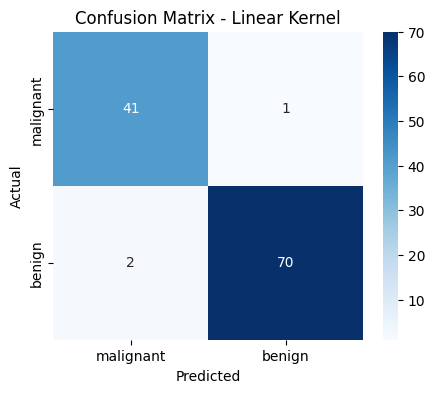

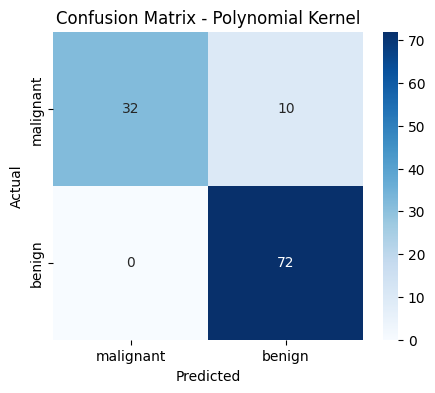

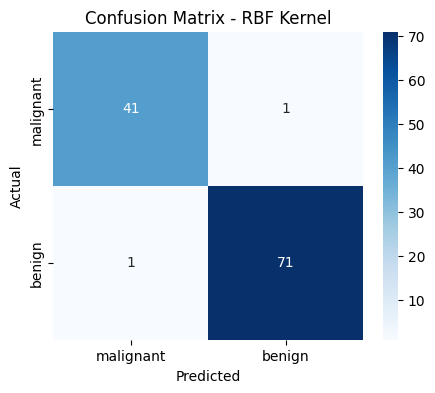

In [ ]:
for name, model in svm_models.items():
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=data.target_names,
                yticklabels=data.target_names)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


## Step 8: Compare Kernel Performances
We compare accuracies of SVM models using different kernels.


In [ ]:
comparison_df = pd.DataFrame({
    "Kernel": list(results.keys()),
    "Accuracy": list(results.values())
}).sort_values(by="Accuracy", ascending=False)

comparison_df


,Kernel,Accuracy
2,RBF Kernel,0.982456
0,Linear Kernel,0.973684
1,Polynomial Kernel,0.912281


## Conclusion
This experiment demonstrates the application of Support Vector Machines (SVM) on a real-world dataset (Breast Cancer Wisconsin Dataset).

### Observations:
- SVM works effectively for tumor classification.
- Performance varies based on kernel selection.
- RBF and Polynomial kernels generally perform better for non-linearly separable datasets.

### Final Outcome:
Kernel selection plays a crucial role in improving classification performance.
